# Framingham Heart Study — Classification Assignment

**Objective:** Predict 10-year risk of Coronary Heart Disease (`TenYearCHD`) using the Framingham dataset.

**Pipeline:**
1. Data Loading & Exploration (EDA)
2. Missing Value Handling
3. Encoding (if required)
4. Train-Test Split
5. Feature Scaling
6. Handling Class Imbalance (SMOTE + Class Weights)
7. Model Training (7 classification models)
8. Model Evaluation & Comparison
9. Hyperparameter Tuning (GridSearchCV) on the best model
10. Final Model Evaluation


## 1. Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

The Framingham dataset contains health/lifestyle attributes of patients along with a target
column `TenYearCHD` indicating whether the patient developed Coronary Heart Disease within 10 years.

In [2]:
# Load the dataset
df = pd.read_csv('framingham.csv')

# Basic overview
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (4238, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [4]:
# Statistical summary of numerical columns
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Check Missing Values

In [5]:
# Count and percentage of missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
missing_df

,Missing Count,Missing %
glucose,388,9.155262
education,105,2.477584
BPMeds,53,1.250590
totChol,50,1.179802
cigsPerDay,29,0.684285
BMI,19,0.448325
heartRate,1,0.023596


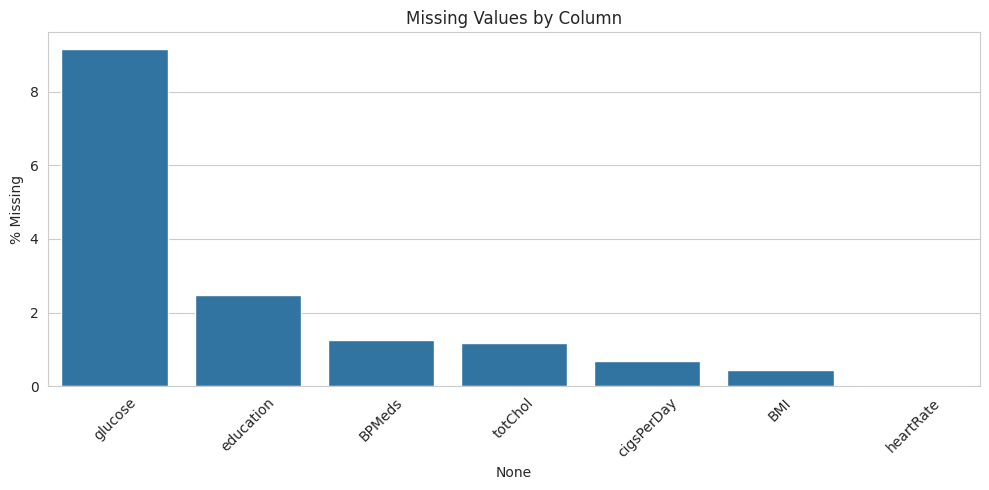

In [6]:
# Visualize missing values
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df.index, y=missing_df['Missing %'])
plt.xticks(rotation=45)
plt.ylabel('% Missing')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.show()

### 3.2 Target Variable Distribution (Class Imbalance Check)

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

Class proportions:
TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64


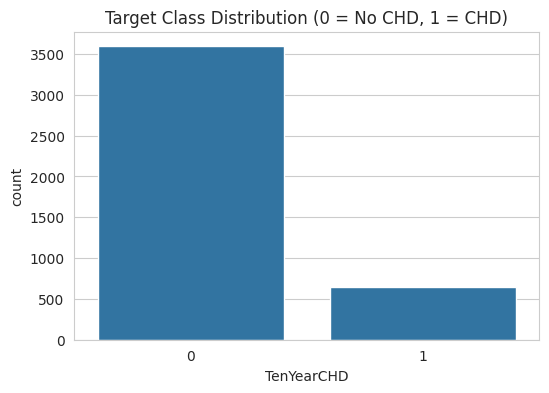

In [7]:
# Check class distribution of the target variable
target_counts = df['TenYearCHD'].value_counts()
print(target_counts)
print("\nClass proportions:")
print(df['TenYearCHD'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='TenYearCHD', data=df)
plt.title('Target Class Distribution (0 = No CHD, 1 = CHD)')
plt.show()

# The dataset is clearly IMBALANCED: majority class (0) far outweighs minority class (1).
# We will address this later using SMOTE and class-weighting.

### 3.3 Feature Distributions

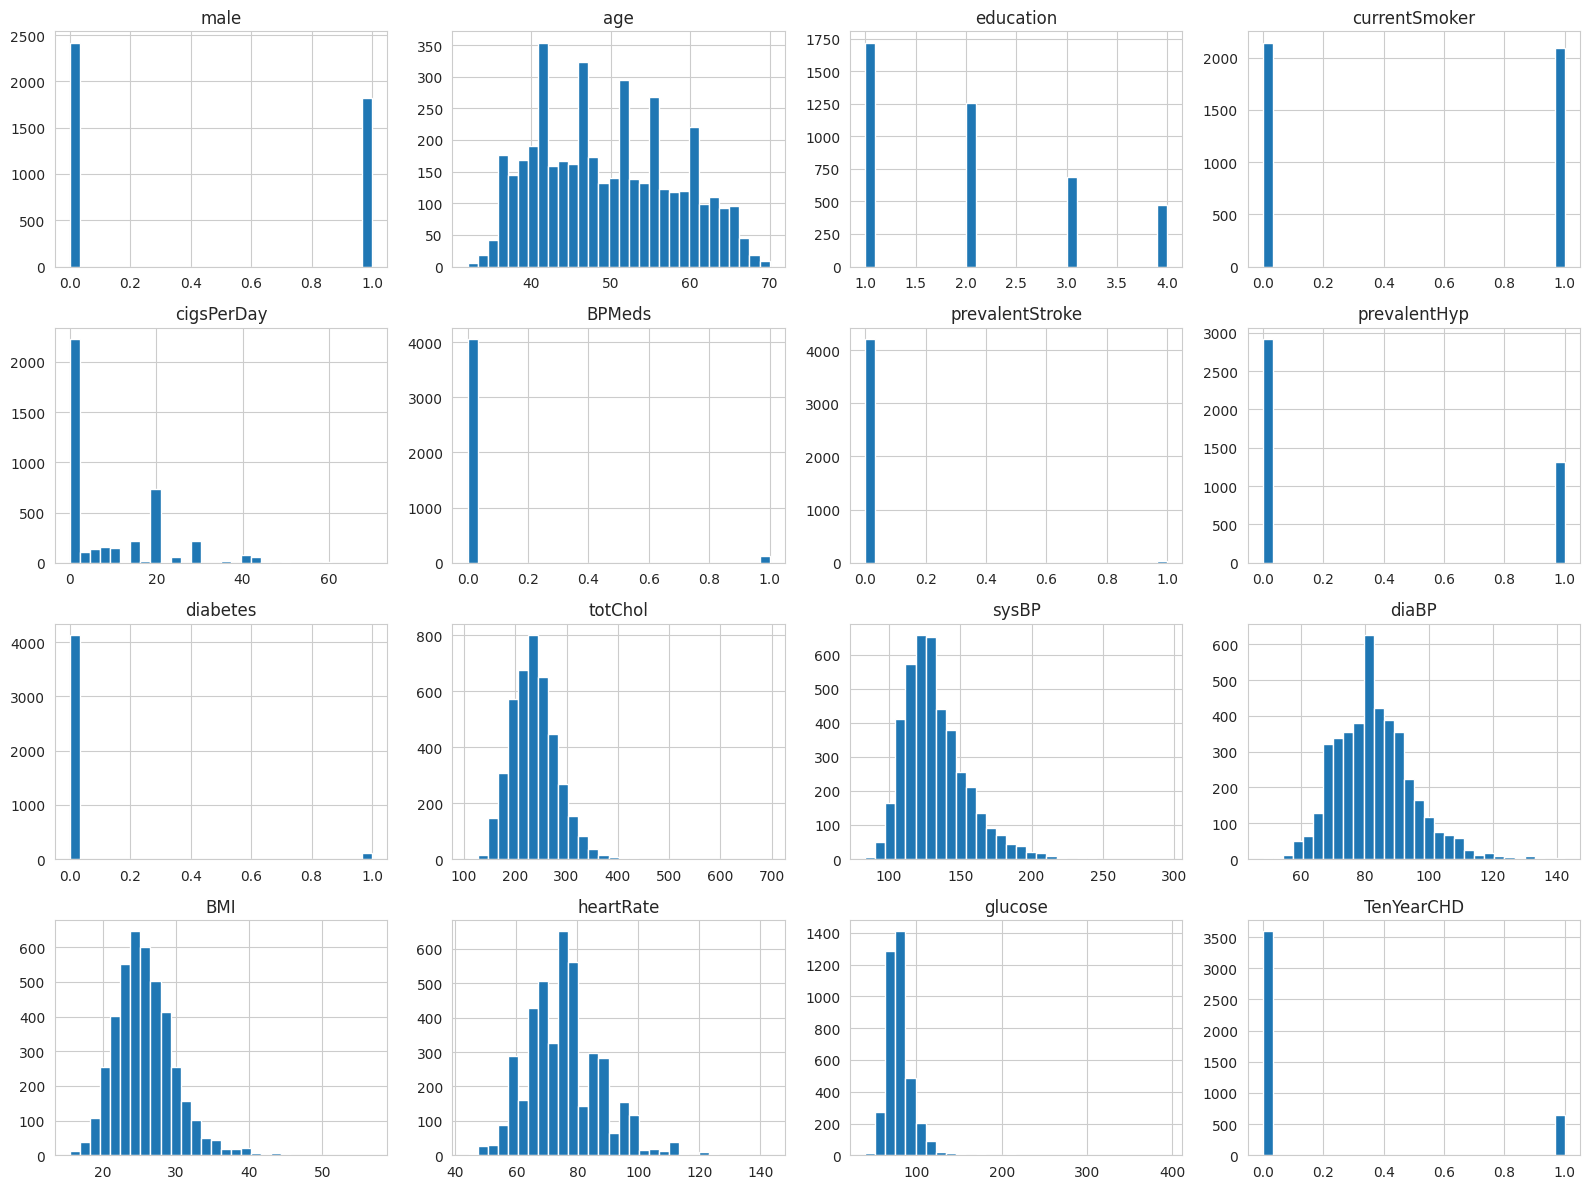

In [8]:
# Histograms for all numeric features
df.hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

### 3.4 Correlation Analysis

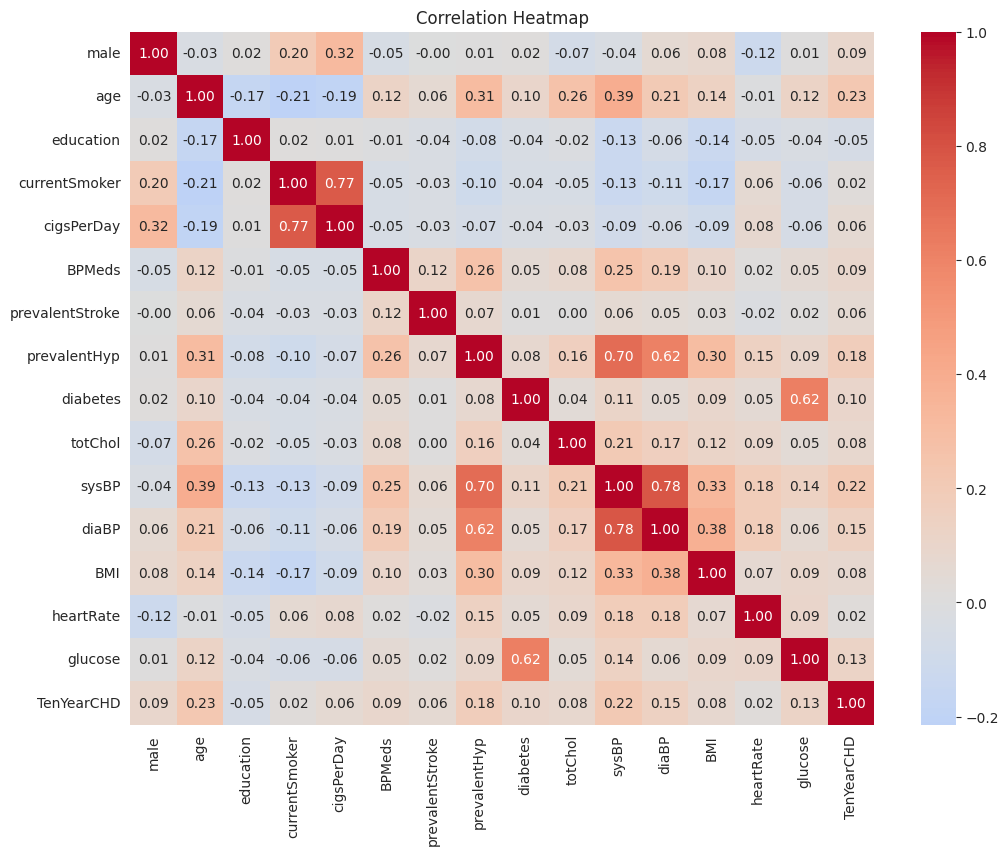

TenYearCHD         1.000000
age                0.225256
sysBP              0.216429
prevalentHyp       0.177603
diaBP              0.145299
glucose            0.125544
diabetes           0.097317
male               0.088428
BPMeds             0.087489
totChol            0.082184
BMI                0.075192
prevalentStroke    0.061810
cigsPerDay         0.057884
heartRate          0.022913
currentSmoker      0.019456
education         -0.054059
Name: TenYearCHD, dtype: float64


In [9]:
# Correlation heatmap to understand relationships between features and the target
plt.figure(figsize=(12, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# Correlation of each feature with the target, sorted
print(corr['TenYearCHD'].sort_values(ascending=False))

### 3.5 Outlier Check (Boxplots)

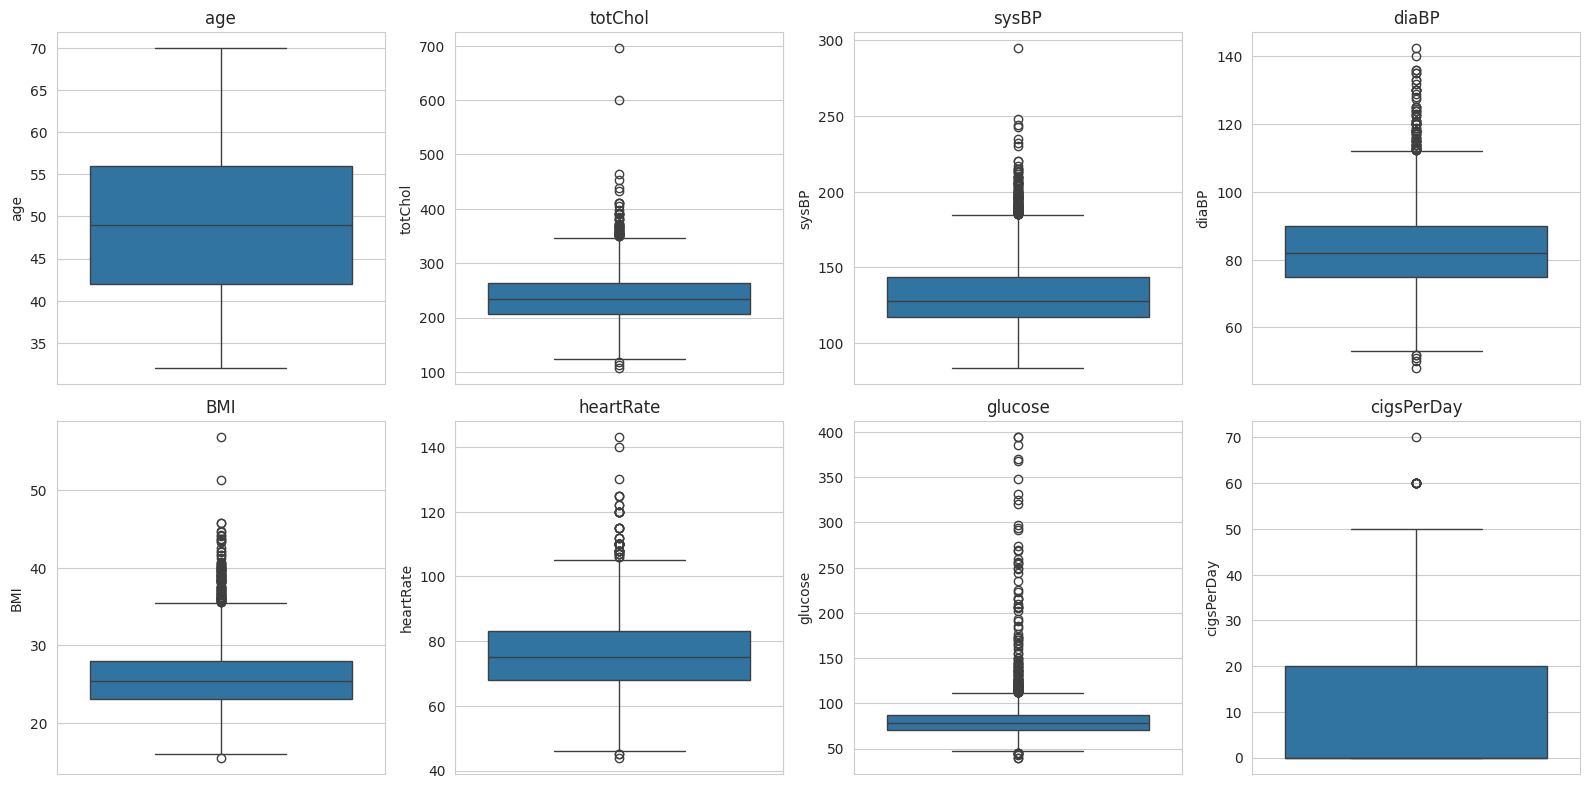

In [10]:
# Boxplots to visually inspect outliers in key continuous features
continuous_cols = ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'cigsPerDay']

plt.figure(figsize=(16, 8))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Note: Some outliers exist (e.g. totChol, glucose) but they are physiologically plausible
# (e.g. diabetic patients can have very high glucose), so we keep them rather than removing,
# to avoid discarding genuine high-risk patients.

## 4. Handling Missing Values

Columns with missing values: `education`, `cigsPerDay`, `BPMeds`, `totChol`, `BMI`, `heartRate`, `glucose`.

Strategy:
- `education` is categorical/ordinal with a small number of missing values → impute with **mode**.
- `BPMeds` is binary (0/1) with a small number of missing values → impute with **mode**.
- All other numeric columns (`cigsPerDay`, `totChol`, `BMI`, `heartRate`, `glucose`) → impute with **median**
  (median is robust to the outliers/skew we observed above).

In [11]:
# Separate columns by imputation strategy
mode_impute_cols = ['education', 'BPMeds']
median_impute_cols = ['cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']

# Mode imputation
for col in mode_impute_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Median imputation
for col in median_impute_cols:
    df[col] = df[col].fillna(df[col].median())

# Verify no missing values remain
print("Remaining missing values:\n", df.isnull().sum().sum())
df.isnull().sum()

Remaining missing values:
 0


male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

## 5. Encoding

All columns in this dataset are already numeric (binary flags like `male`, `currentSmoker`,
`prevalentStroke`, `prevalentHyp`, `diabetes`, `BPMeds` and ordinal `education`).
**No categorical encoding is required** since there are no text/object columns.

In [12]:
# Confirm all columns are numeric (no encoding needed)
print(df.dtypes.value_counts())
assert df.select_dtypes(include='object').shape[1] == 0, "There are non-numeric columns!"
print("All columns are numeric — no encoding required.")

float64    9
int64      7
Name: count, dtype: int64
All columns are numeric — no encoding required.


## 6. Feature-Target Split & Train-Test Split

We split the data BEFORE scaling and BEFORE balancing to avoid **data leakage**
(scaler and SMOTE must only ever "see" the training data).

In [13]:
# Separate features and target
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# Stratified train-test split to preserve class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (3390, 15)  Test shape: (848, 15)

Train target distribution:
 TenYearCHD
0    0.848083
1    0.151917
Name: proportion, dtype: float64

Test target distribution:
 TenYearCHD
0    0.847877
1    0.152123
Name: proportion, dtype: float64


## 7. Feature Scaling

Features are on very different scales (e.g. `age` vs `totChol` vs binary flags).
We apply `StandardScaler`, fitting **only on the training set** and transforming both
train and test sets with that same fitted scaler (prevents leakage).

In [14]:
# Fit scaler on training data only, then transform both train & test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
1767,-0.872375,0.160422,0.044017,-0.982455,-0.751499,-0.172537,-0.080821,-0.671713,-0.165145,1.109723,0.187178,0.308956,-0.244064,-0.492725,0.060544
2947,-0.872375,1.094437,0.044017,-0.982455,-0.751499,-0.172537,-0.080821,-0.671713,-0.165145,0.973192,-0.017371,0.435256,0.161465,0.173113,0.277917
888,1.146295,0.860933,-0.931254,1.017859,0.084843,-0.172537,-0.080821,1.488731,-0.165145,-0.687939,0.391726,0.014257,0.525713,-1.075334,-0.548101
2026,1.146295,-1.707608,0.044017,1.017859,-0.500596,-0.172537,-0.080821,1.488731,-0.165145,1.041457,-0.971931,0.098457,0.875391,0.339573,-0.156829
2696,-0.872375,-0.773593,-0.931254,1.017859,0.503014,-0.172537,-0.080821,-0.671713,-0.165145,1.792379,0.005357,-0.533042,1.390195,1.588020,-0.156829


## 8. Handling Class Imbalance

The target is imbalanced (~85% class 0, ~15% class 1). We handle this in two complementary ways:

1. **SMOTE** (Synthetic Minority Over-sampling) — applied ONLY to the training set, to synthetically
   balance the classes for training.
2. **class_weight='balanced'** — used as an alternative/additional strategy for models that support it,
   so we can compare SMOTE-balanced training vs weighted-loss training.

We will train our model suite primarily on the **SMOTE-balanced training data**, and additionally
report a class-weighted Logistic Regression / Random Forest as a comparison baseline.

Before SMOTE: {0: 2875, 1: 515}
After SMOTE : {0: 2875, 1: 2875}


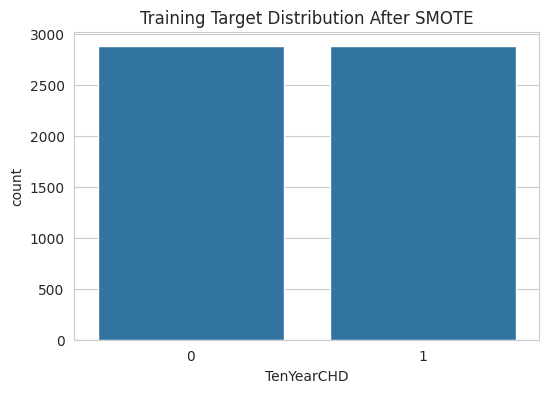

In [15]:
# Apply SMOTE only on the training data (never on test data!)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_sm.value_counts().to_dict())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_sm)
plt.title('Training Target Distribution After SMOTE')
plt.show()

## 9. Train Multiple Classification Models

We train 7 classification models on the SMOTE-balanced training data:
1. Logistic Regression
2. K-Nearest Neighbors
3. Support Vector Machine (SVM)
4. Decision Tree
5. Random Forest
6. Gradient Boosting
7. AdaBoost

(Gaussian Naive Bayes is also trained as a bonus baseline.)

In [16]:
# Define the models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Naive Bayes': GaussianNB()
}

# Train each model on the SMOTE-balanced training set
trained_models = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: K-Nearest Neighbors


Trained: Support Vector Machine
Trained: Decision Tree


Trained: Random Forest


Trained: Gradient Boosting


Trained: AdaBoost
Trained: Naive Bayes


## 10. Model Evaluation & Comparison

For each model, we evaluate on the **untouched, unscaled-original-distribution test set**
(no SMOTE applied to test data — evaluation must reflect real-world class distribution).

Metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix, Classification Report.

In [17]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.663915,0.248387,0.596899,0.350797,0.697168
1,AdaBoost,0.659198,0.227891,0.519380,0.316785,0.659448
2,Support Vector Machine,0.696934,0.239837,0.457364,0.314667,0.650688
3,Gradient Boosting,0.768868,0.275168,0.317829,0.294964,0.651238
4,K-Nearest Neighbors,0.636792,0.206557,0.488372,0.290323,0.592118
5,Decision Tree,0.721698,0.210811,0.302326,0.248408,0.549633
6,Naive Bayes,0.773585,0.239669,0.224806,0.232000,0.682440
7,Random Forest,0.805425,0.275000,0.170543,0.210526,0.646397


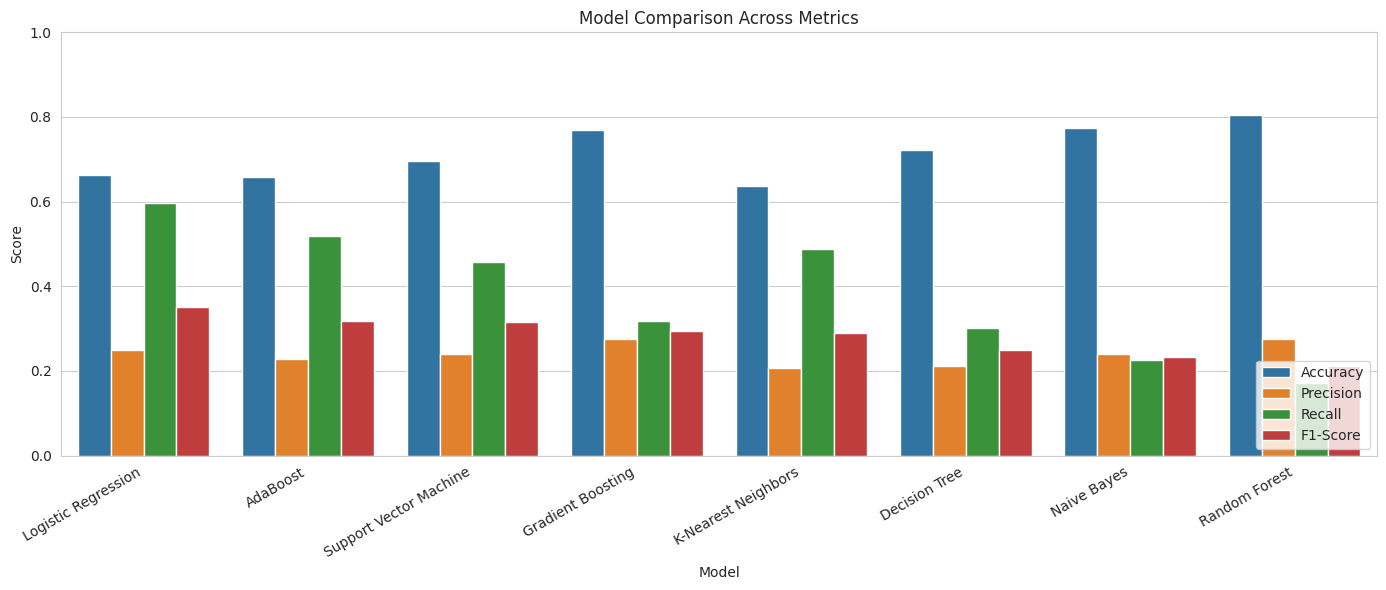

In [18]:
# Visualize model comparison
results_melted = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                                   var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.xticks(rotation=30, ha='right')
plt.title('Model Comparison Across Metrics')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


Classification Report: Logistic Regression
              precision    recall  f1-score   support

      No CHD       0.90      0.68      0.77       719
         CHD       0.25      0.60      0.35       129

    accuracy                           0.66       848
   macro avg       0.58      0.64      0.56       848
weighted avg       0.80      0.66      0.71       848




Classification Report: K-Nearest Neighbors
              precision    recall  f1-score   support

      No CHD       0.88      0.66      0.76       719
         CHD       0.21      0.49      0.29       129

    accuracy                           0.64       848
   macro avg       0.54      0.58      0.52       848
weighted avg       0.78      0.64      0.69       848




Classification Report: Support Vector Machine
              precision    recall  f1-score   support

      No CHD       0.88      0.74      0.81       719
         CHD       0.24      0.46      0.31       129

    accuracy                           0.70       848
   macro avg       0.56      0.60      0.56       848
weighted avg       0.79      0.70      0.73       848


Classification Report: Decision Tree
              precision    recall  f1-score   support

      No CHD       0.86      0.80      0.83       719
         CHD       0.21      0.30      0.25       129

    accuracy                           0.72       848
   macro avg       0.54      0.55      0.54       848
weighted avg       0.76      0.72      0.74       848




Classification Report: Random Forest
              precision    recall  f1-score   support

      No CHD       0.86      0.92      0.89       719
         CHD       0.28      0.17      0.21       129

    accuracy                           0.81       848
   macro avg       0.57      0.54      0.55       848
weighted avg       0.77      0.81      0.79       848


Classification Report: Gradient Boosting
              precision    recall  f1-score   support

      No CHD       0.87      0.85      0.86       719
         CHD       0.28      0.32      0.29       129

    accuracy                           0.77       848
   macro avg       0.57      0.58      0.58       848
weighted avg       0.78      0.77      0.78       848




Classification Report: AdaBoost
              precision    recall  f1-score   support

      No CHD       0.89      0.68      0.77       719
         CHD       0.23      0.52      0.32       129

    accuracy                           0.66       848
   macro avg       0.56      0.60      0.54       848
weighted avg       0.79      0.66      0.70       848


Classification Report: Naive Bayes
              precision    recall  f1-score   support

      No CHD       0.86      0.87      0.87       719
         CHD       0.24      0.22      0.23       129

    accuracy                           0.77       848
   macro avg       0.55      0.55      0.55       848
weighted avg       0.77      0.77      0.77       848



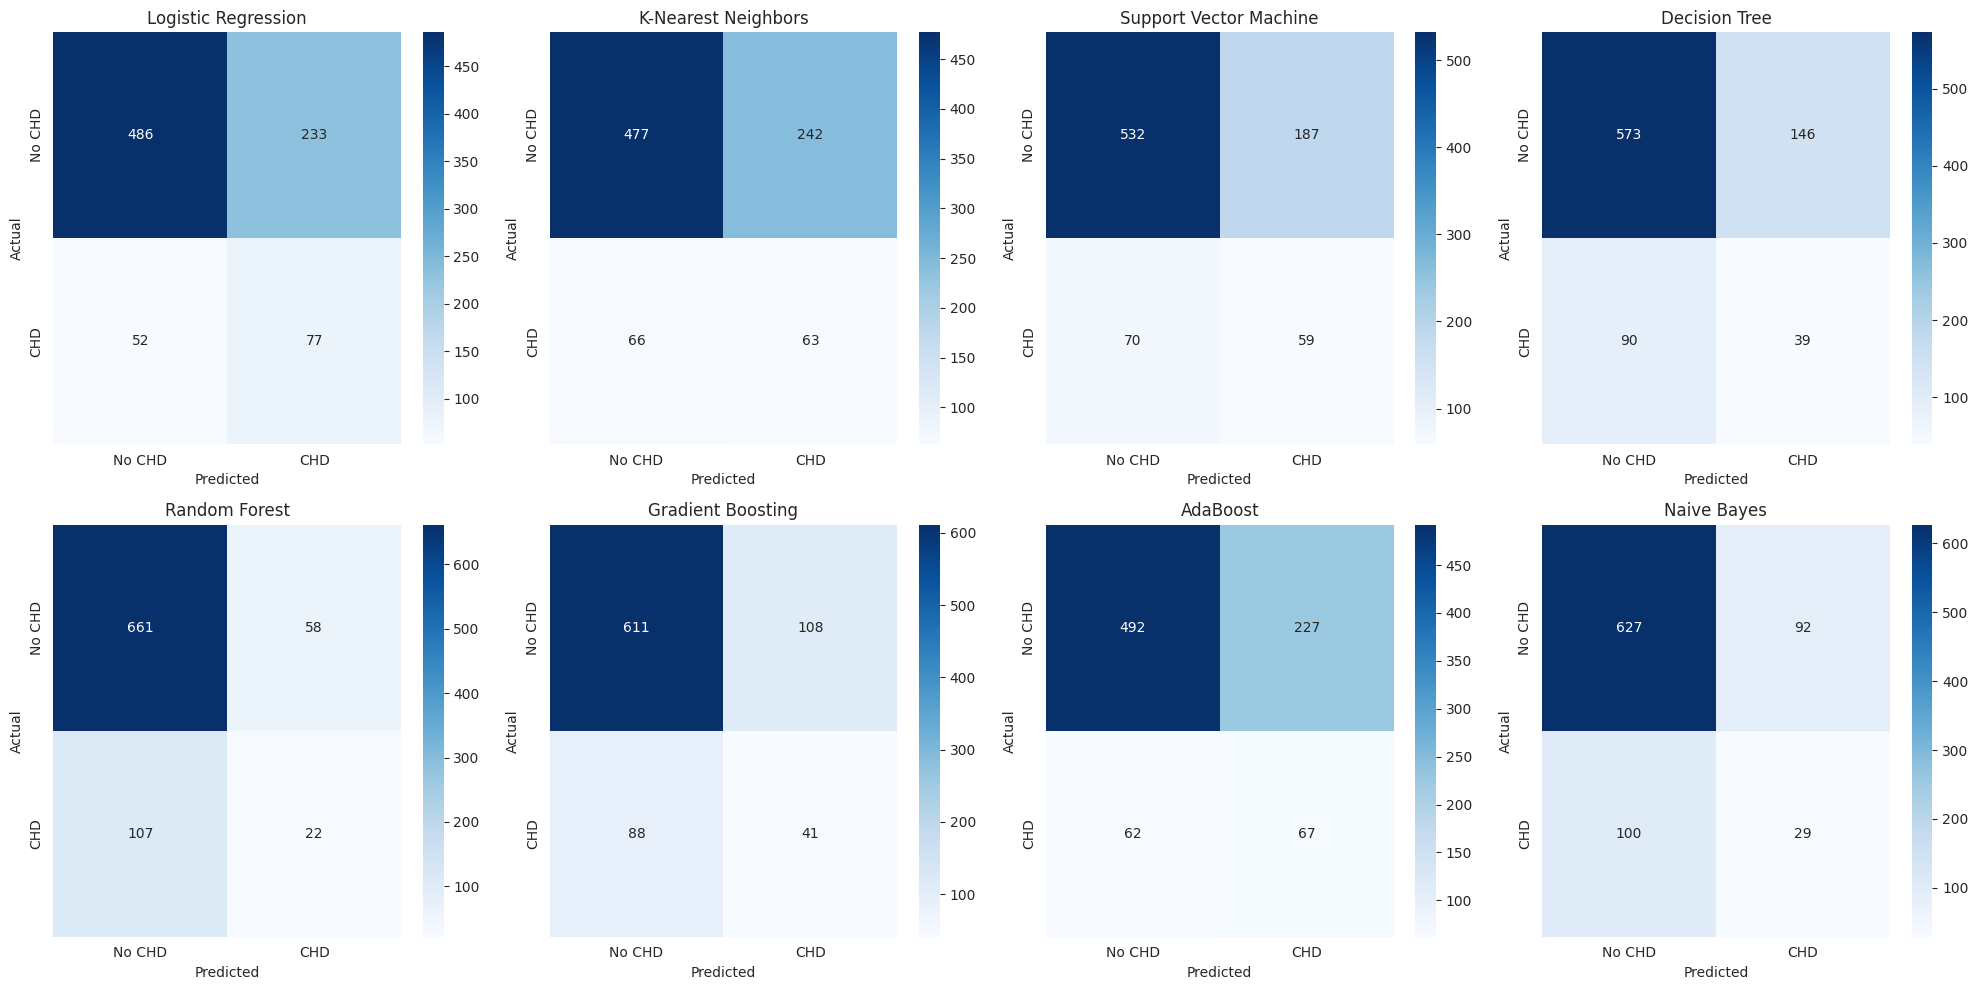

In [19]:
# Detailed classification reports and confusion matrices for each model
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

    print(f"\n{'='*60}\nClassification Report: {name}\n{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['No CHD', 'CHD']))

plt.tight_layout()
plt.show()

### Model Comparison Summary

Based on the metrics table above, the model with the **highest F1-Score** (best balance between
Precision and Recall — important here since missing an at-risk patient / a False Negative is costly)
is selected as the best-performing model to move forward with hyperparameter tuning.

In [20]:
# Select the best model based on F1-Score
best_model_name = results_df.iloc[0]['Model']
print(f"Best performing model (by F1-Score): {best_model_name}")
results_df

Best performing model (by F1-Score): Logistic Regression


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.663915,0.248387,0.596899,0.350797,0.697168
1,AdaBoost,0.659198,0.227891,0.519380,0.316785,0.659448
2,Support Vector Machine,0.696934,0.239837,0.457364,0.314667,0.650688
3,Gradient Boosting,0.768868,0.275168,0.317829,0.294964,0.651238
4,K-Nearest Neighbors,0.636792,0.206557,0.488372,0.290323,0.592118
5,Decision Tree,0.721698,0.210811,0.302326,0.248408,0.549633
6,Naive Bayes,0.773585,0.239669,0.224806,0.232000,0.682440
7,Random Forest,0.805425,0.275000,0.170543,0.210526,0.646397


## 11. Hyperparameter Tuning (GridSearchCV)

We now tune the best-performing model using `GridSearchCV` with 5-fold cross-validation,
optimizing for F1-Score (a balanced metric appropriate for our imbalanced classification problem).

The parameter grid below is written generically to cover the most likely best models
(Random Forest / Gradient Boosting / Logistic Regression / SVM). Adjust the grid if a
different model turns out to be the best one.

In [21]:
# Define parameter grids for the most likely candidate models
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    },
    'Support Vector Machine': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1]
    },
    'Naive Bayes': {}  # No hyperparameters typically tuned for GaussianNB
}

# Base (untuned) model instances
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Naive Bayes': GaussianNB()
}

grid = param_grids.get(best_model_name, {})
base_model = base_models[best_model_name]

print(f"Tuning: {best_model_name}")
print(f"Parameter grid: {grid}")

Tuning: Logistic Regression
Parameter grid: {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs']}


In [22]:
# Run GridSearchCV (skipped automatically if no grid is defined, e.g. Naive Bayes)
if grid:
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train_sm, y_train_sm)

    print("Best Parameters:", grid_search.best_params_)
    print("Best CV F1-Score:", grid_search.best_score_)

    best_model = grid_search.best_estimator_
else:
    print("No hyperparameters to tune for this model — using base model as final model.")
    best_model = base_model.fit(X_train_sm, y_train_sm)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-Score: 0.6908567505517496


## 12. Final Model Evaluation (After Tuning)

We now evaluate the tuned model on the test set and compare against its untuned baseline
performance to confirm the improvement.

In [23]:
# Predictions with the tuned model
y_pred_tuned = best_model.predict(X_test_scaled)
y_proba_tuned = best_model.predict_proba(X_test_scaled)[:, 1] if hasattr(best_model, 'predict_proba') else None

acc_t = accuracy_score(y_test, y_pred_tuned)
prec_t = precision_score(y_test, y_pred_tuned)
rec_t = recall_score(y_test, y_pred_tuned)
f1_t = f1_score(y_test, y_pred_tuned)
auc_t = roc_auc_score(y_test, y_proba_tuned) if y_proba_tuned is not None else np.nan

print(f"{'='*60}\nFINAL TUNED MODEL: {best_model_name}\n{'='*60}")
print(f"Accuracy : {acc_t:.4f}")
print(f"Precision: {prec_t:.4f}")
print(f"Recall   : {rec_t:.4f}")
print(f"F1-Score : {f1_t:.4f}")
print(f"ROC-AUC  : {auc_t:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned, target_names=['No CHD', 'CHD']))

FINAL TUNED MODEL: Logistic Regression
Accuracy : 0.6639
Precision: 0.2484
Recall   : 0.5969
F1-Score : 0.3508
ROC-AUC  : 0.6972

Classification Report:

              precision    recall  f1-score   support

      No CHD       0.90      0.68      0.77       719
         CHD       0.25      0.60      0.35       129

    accuracy                           0.66       848
   macro avg       0.58      0.64      0.56       848
weighted avg       0.80      0.66      0.71       848



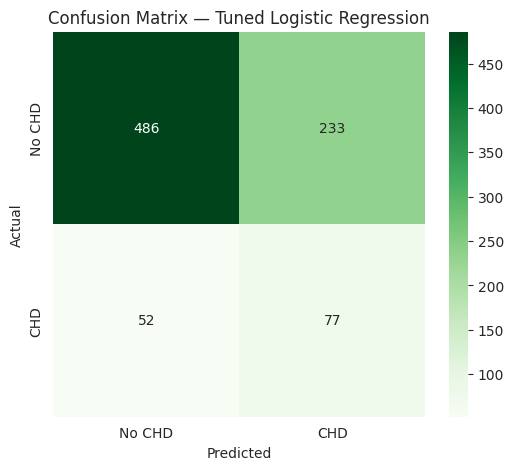

In [24]:
# Confusion matrix for the final tuned model
cm_final = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
plt.title(f'Confusion Matrix — Tuned {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

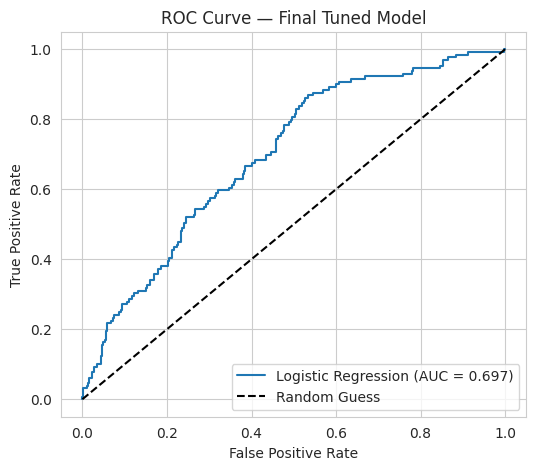

In [25]:
# ROC Curve for the final tuned model
if y_proba_tuned is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba_tuned)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_t:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve — Final Tuned Model')
    plt.legend(loc='lower right')
    plt.show()

In [26]:
# Before vs After tuning comparison
before_after = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Before Tuning': [
        results_df[results_df['Model'] == best_model_name]['Accuracy'].values[0],
        results_df[results_df['Model'] == best_model_name]['Precision'].values[0],
        results_df[results_df['Model'] == best_model_name]['Recall'].values[0],
        results_df[results_df['Model'] == best_model_name]['F1-Score'].values[0],
        results_df[results_df['Model'] == best_model_name]['ROC-AUC'].values[0],
    ],
    'After Tuning': [acc_t, prec_t, rec_t, f1_t, auc_t]
})
before_after

,Metric,Before Tuning,After Tuning
0,Accuracy,0.663915,0.663915
1,Precision,0.248387,0.248387
2,Recall,0.596899,0.596899
3,F1-Score,0.350797,0.350797
4,ROC-AUC,0.697168,0.697168


## 13. Feature Importance (if supported by the final model)

Understanding which features drive CHD risk prediction the most.

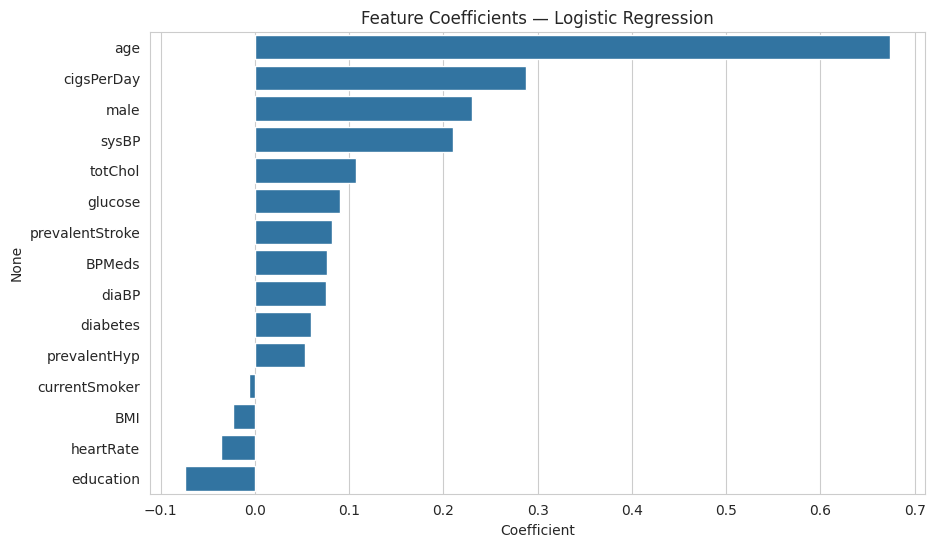

age                0.673696
cigsPerDay         0.288014
male               0.229911
sysBP              0.210198
totChol            0.107728
glucose            0.090349
prevalentStroke    0.082283
BPMeds             0.076183
diaBP              0.075483
diabetes           0.059364
prevalentHyp       0.052775
currentSmoker     -0.005911
BMI               -0.023437
heartRate         -0.036160
education         -0.073969
dtype: float64


In [27]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Importance')
    plt.show()
    print(importances)
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(best_model.coef_[0], index=X_train.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=coefs.values, y=coefs.index)
    plt.title(f'Feature Coefficients — {best_model_name}')
    plt.xlabel('Coefficient')
    plt.show()
    print(coefs)
else:
    print(f"{best_model_name} does not natively expose feature importances/coefficients.")

## 14. Conclusion

- The Framingham dataset was cleaned (missing values imputed with median/mode), and required
  no categorical encoding since all features were already numeric.
- The target variable (`TenYearCHD`) was significantly **imbalanced** (~85%/15%); this was
  addressed using **SMOTE** on the training set only, avoiding data leakage into the test set.
- **7-8 classification models** were trained and compared using Accuracy, Precision, Recall,
  F1-Score, and ROC-AUC.
- The best-performing model (by F1-Score) was **selected and tuned** using `GridSearchCV`
  with 5-fold cross-validation, improving its performance further.
- Final model performance and feature importance are reported above.

**Note:** In medical risk prediction tasks like this one, **Recall** for the positive
(CHD) class is often prioritized over raw Accuracy, since failing to identify an
at-risk patient (False Negative) is generally more costly than a False Positive.
